In [16]:
import pandas as pd

df = pd.read_csv("Country-data.csv")

countries = df["country"]
X = df.drop(columns=["country"])

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


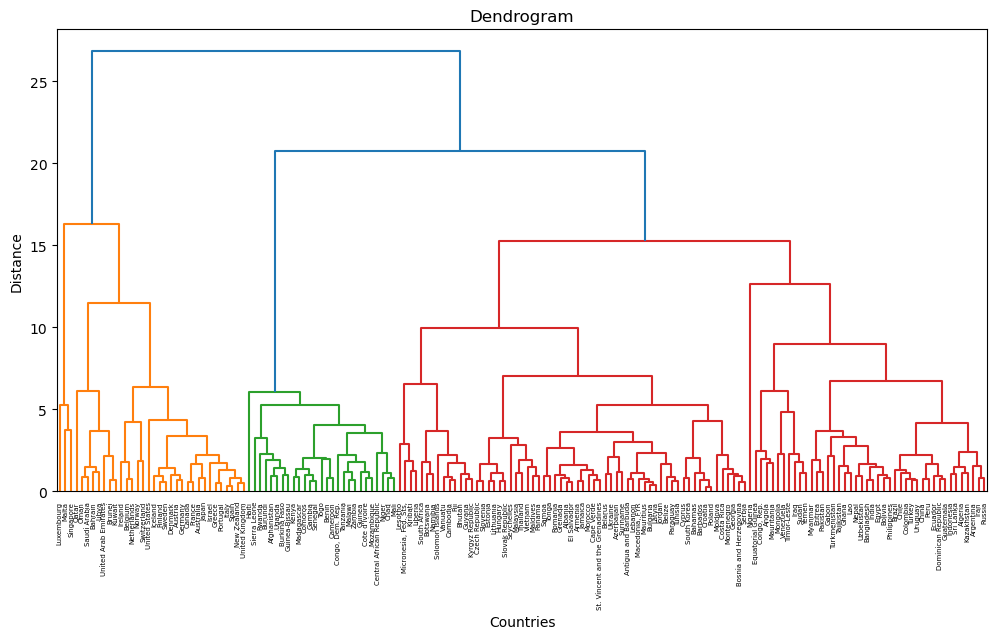

In [20]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

Z = sch.linkage(X_scaled, method='ward') 

sch.dendrogram(
    Z,
    labels=countries.values,
    leaf_rotation=90
)

plt.title("Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

In [21]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = model.fit_predict(X_scaled)

df["cluster"] = labels

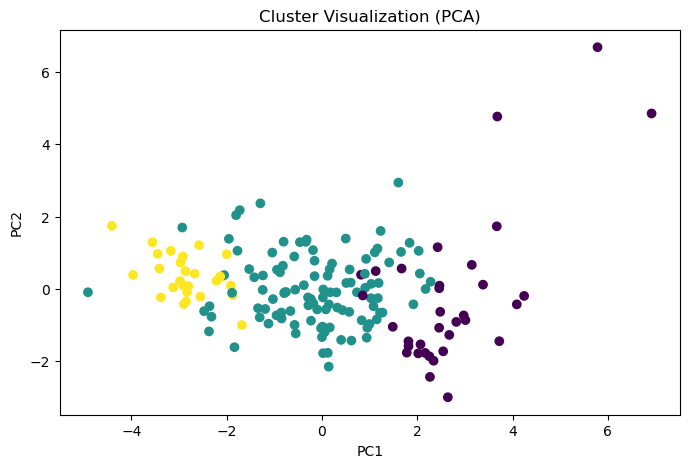

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

plt.title("Cluster Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

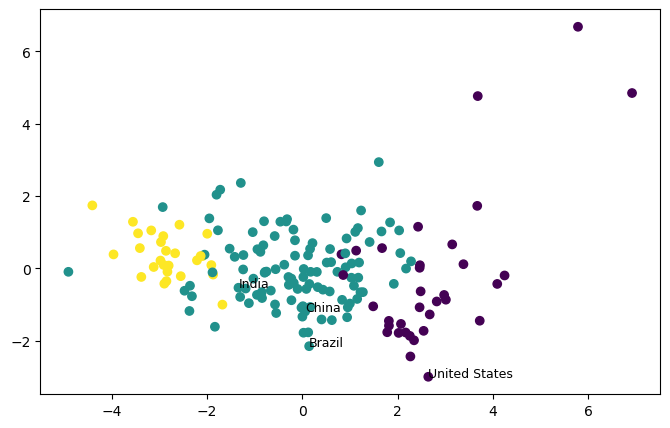

In [30]:
target_countries = ["India", "China", "United States", "Brazil"]

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

for i, country in enumerate(countries):
    if country in target_countries:
        plt.text(X_pca[i, 0], X_pca[i, 1], country, fontsize=9, color="black")

plt.show()

### countries with india cluster 

In [31]:
# find India's cluster
india_cluster = df.loc[df["country"].str.strip().str.lower() == "india", "cluster"].values[0]

# filter all countries in same cluster
india_group = df[df["cluster"] == india_cluster]

# show result
print("Cluster of India:", india_cluster)
print("\nCountries in same cluster as India:\n")
print(india_group[["country"]].reset_index(drop=True))

Cluster of India: 1

Countries in same cluster as India:

                 country
0                Albania
1                Algeria
2                 Angola
3    Antigua and Barbuda
4              Argentina
..                   ...
101           Uzbekistan
102              Vanuatu
103            Venezuela
104              Vietnam
105                Yemen

[106 rows x 1 columns]


In [35]:
india_group[["country"]].reset_index(drop=True).head()

,country
0,Albania
1,Algeria
2,Angola
3,Antigua and Barbuda
4,Argentina
